#0. PREPROCESSING

In [ ]:
# Loading Dataset from Huggingface & Imports
# 0. Imports
import numpy as np
from sklearn import preprocessing
from sklearn.preprocessing import StandardScaler
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.decomposition import PCA
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# 1. Loading Dataset
df = pd.read_csv("hf://datasets/maharshipandya/spotify-tracks-dataset/dataset.csv")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


In [ ]:
# Dataset Description (Hady)
# 2. Size and Shape
print(f"Dataset Shape: {df.shape}")
print(f"Number of Records: {len(df)}")
print(f"Number of Features: {len(df.columns)}")

# 3. Feature Types and Names
print("\nFeature Information:")
print(df.info())

# 4. Class Labels and Distribution
print("\nClass Distribution:")
print(df['track_genre'].value_counts().sort_values(ascending=True))

# 5. Descriptive Statistics
print("\nDescriptive Statistics for Features:")
stats = df[['popularity', 'duration_ms', 'danceability', 'energy',
            'loudness', 'speechiness', 'acousticness', 'instrumentalness',
            'liveness', 'valence', 'tempo']].describe()
print(stats)

Dataset Shape: (114000, 21)
Number of Records: 114000
Number of Features: 21

Feature Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 114000 entries, 0 to 113999
Data columns (total 21 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Unnamed: 0        114000 non-null  int64  
 1   track_id          114000 non-null  object 
 2   artists           113999 non-null  object 
 3   album_name        113999 non-null  object 
 4   track_name        113999 non-null  object 
 5   popularity        114000 non-null  int64  
 6   duration_ms       114000 non-null  int64  
 7   explicit          114000 non-null  bool   
 8   danceability      114000 non-null  float64
 9   energy            114000 non-null  float64
 10  key               114000 non-null  int64  
 11  loudness          114000 non-null  float64
 12  mode              114000 non-null  int64  
 13  speechiness       114000 non-null  float64
 14  acousticness     

In [ ]:
# Preprocessing (Hady)
# 6. Check for Missing Values
print("\nMissing Values per Feature:")
print(df.isnull().sum())

# Finding and printing the rows with missing values
missing_row = df[df.isnull().any(axis=1)]
print("\nRecord/s with missing values:")
print(missing_row)

# Dropping missing record
df = df.dropna()

# Verifying that the record is gone
print(f"\nDataset shape: {df.shape}")
print(f"Total missing values remaining: {df.isnull().sum().sum()}")


Missing Values per Feature:
Unnamed: 0          0
track_id            0
artists             1
album_name          1
track_name          1
popularity          0
duration_ms         0
explicit            0
danceability        0
energy              0
key                 0
loudness            0
mode                0
speechiness         0
acousticness        0
instrumentalness    0
liveness            0
valence             0
tempo               0
time_signature      0
track_genre         0
dtype: int64

Record/s with missing values:
       Unnamed: 0                track_id artists album_name track_name  \
65900       65900  1kR4gIb7nGxHPI3D2ifs59     NaN        NaN        NaN   

       popularity  duration_ms  explicit  danceability  energy  ...  loudness  \
65900           0            0     False         0.501   0.583  ...     -9.46   

       mode  speechiness  acousticness  instrumentalness  liveness  valence  \
65900     0       0.0605          0.69           0.00396    0.0747    0.

In [ ]:
# 7. Dropping metadata and csv id/index columns (Hady)
# List of columns to be removed
cols_to_drop = ['Unnamed: 0', 'track_id', 'artists', 'album_name', 'track_name']

# Dropping the metadata columns
df = df.drop(columns=cols_to_drop)

# Verifying the remaining features
print("Remaining columns in the dataset:")
print(df.columns.tolist())
print(f"\nShape after dropping columns: {df.shape}")

Remaining columns in the dataset:
['popularity', 'duration_ms', 'explicit', 'danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'time_signature', 'track_genre']

Shape after dropping columns: (113999, 16)


In [ ]:
# 8. Binary Encoding (Hady)
# Convert 'explicit' to binary (0 and 1)
df['explicit'] = df['explicit'].astype(int)
# df['mode'] = df['mode'].astype(int) - does not require conversion as is already in binary format

# Verifying the conversion
print("Values after conversion:")
print(df['explicit'].value_counts())
print(df['mode'].value_counts())

Values after conversion:
explicit
0    104252
1      9747
Name: count, dtype: int64
mode
1    72681
0    41318
Name: count, dtype: int64


In [ ]:
# 9. One-hot encoding (Hady)
# Columns to encode
X = df[['key', 'time_signature']]

# Creating the encoder, fitting and transforming data
enc = preprocessing.OneHotEncoder()
encoded_array = enc.fit_transform(X).toarray()

# To extract the feature names
new_columns = enc.get_feature_names_out(['key', 'time_signature'])

# Creating a new DataFrame with the array
encoded_df = pd.DataFrame(encoded_array, columns=new_columns, index=df.index)

# Dropping the original columns and attaching the new encoded ones
df = df.drop(columns=['key', 'time_signature'])
df = pd.concat([df, encoded_df], axis=1)

print(f"Dataset shape: {df.shape}")

Dataset shape: (113999, 31)


In [ ]:
# 10. Label Encoding (Hady)
# Creating the LabelEncoder object
le = preprocessing.LabelEncoder()

# Fitting the encoder and transforming the track_genre column
df['track_genre'] = le.fit_transform(df['track_genre'])

# Verifying the transformation
print(f"\nTotal unique classes: {df['track_genre'].nunique()}")
print(f"Minimum label ID: {df['track_genre'].min()}")
print(f"Maximum label ID: {df['track_genre'].max()}")


Total unique classes: 114
Minimum label ID: 0
Maximum label ID: 113


In [ ]:
# 11. Scaling (Hady)
# Listing all continuous features
continuous_features = [
    'popularity', 'duration_ms', 'danceability', 'energy',
    'loudness', 'speechiness', 'acousticness', 'instrumentalness',
    'liveness', 'valence', 'tempo'
]

# Initializing and apply the scaler
scaler = StandardScaler()
df[continuous_features] = scaler.fit_transform(df[continuous_features])

# 0.5 PRE-TRAINING

In [ ]:
# Separate features and target (Arya)
X = df.drop(columns=['track_genre'])
y = df['track_genre']

# 80-20 Split with Stratification for 114 classes
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print(f"Training samples: {len(X_train)}")
print(f"Testing samples: {len(X_test)}")

Training samples: 91199
Testing samples: 22800


In [ ]:
# Fit PCA to training data (Hady)
pca_full = PCA().fit(X_train)
cumulative_variance = np.cumsum(pca_full.explained_variance_ratio_)

# Find components for 90% variance (Found: 12)
p = np.argmax(cumulative_variance >= 0.90) + 1
print(f"Optimal PCA components (p): {p}")

pca_final = PCA(n_components=p)
X_train_pca = pca_final.fit_transform(X_train)
X_test_pca = pca_final.transform(X_test)

Optimal PCA components (p): 12


# 1. DECISION TREES ( Hady )

In [ ]:
# Run 1: Coarse Search for best tree depth
for d in [10, 20, 30, 40, 50]:
    dt = DecisionTreeClassifier(max_depth=d, random_state=42)
    score = cross_val_score(dt, X_train_pca, y_train, cv=5, scoring='f1_macro').mean()
    print(f"Coarse Depth {d}: F1 = {score:.4f}")

Coarse Depth 10: F1 = 0.1190
Coarse Depth 20: F1 = 0.1756
Coarse Depth 30: F1 = 0.1687
Coarse Depth 40: F1 = 0.1688
Coarse Depth 50: F1 = 0.1687


In [ ]:
# Run 2: Fine Search (Zooming in on the peak at 20)
for d in [15, 16, 17, 18, 19]:
    dt = DecisionTreeClassifier(max_depth=d, random_state=42)
    score = cross_val_score(dt, X_train_pca, y_train, cv=5, scoring='f1_macro').mean()
    print(f"Fine Depth {d}: F1 = {score:.4f}")

# Best Depth: 16

Fine Depth 15: F1 = 0.1742
Fine Depth 16: F1 = 0.1787
Fine Depth 17: F1 = 0.1779
Fine Depth 18: F1 = 0.1784
Fine Depth 19: F1 = 0.1760


In [ ]:
# Run 1: Coarse Search for best min sample split
for s in [5, 10, 25, 50, 100]:
    dt = DecisionTreeClassifier(min_samples_split=s, random_state=42)
    score = cross_val_score(dt, X_train_pca, y_train, cv=5, scoring='f1_macro').mean()
    print(f"Coarse Split {s}: F1 = {score:.4f}")

Coarse Split 5: F1 = 0.1669
Coarse Split 10: F1 = 0.1721
Coarse Split 25: F1 = 0.1811
Coarse Split 50: F1 = 0.1831
Coarse Split 100: F1 = 0.1789


In [ ]:
# Run 2: Fine Search (Zooming in on the plateau near 50)
for s in [41, 42, 43, 44, 45]:
    dt = DecisionTreeClassifier(min_samples_split=s, random_state=42)
    score = cross_val_score(dt, X_train_pca, y_train, cv=5, scoring='f1_macro').mean()
    print(f"Fine Split {s}: F1 = {score:.4f}")

# Best Split: 45

Fine Split 41: F1 = 0.1834
Fine Split 42: F1 = 0.1836
Fine Split 43: F1 = 0.1838
Fine Split 44: F1 = 0.1836
Fine Split 45: F1 = 0.1838


In [ ]:
# Run 1: Coarse Search for best min samples leaf
for l in [1, 5, 10, 25, 50, 100]:
    dt = DecisionTreeClassifier(min_samples_leaf=l, random_state=42)
    score = cross_val_score(dt, X_train_pca, y_train, cv=5, scoring='f1_macro').mean()
    print(f"Coarse Leaf {l}: F1 = {score:.4f}")

Coarse Leaf 1: F1 = 0.1687
Coarse Leaf 5: F1 = 0.1744
Coarse Leaf 10: F1 = 0.1805
Coarse Leaf 25: F1 = 0.1818
Coarse Leaf 50: F1 = 0.1728
Coarse Leaf 100: F1 = 0.1593


In [ ]:
# Run 2: Fine Search (Zooming in on the peak at 25)
for l in [15, 16, 17, 18, 19]:
    dt = DecisionTreeClassifier(min_samples_leaf=l, random_state=42)
    score = cross_val_score(dt, X_train_pca, y_train, cv=5, scoring='f1_macro').mean()
    print(f"Fine Leaf {l}: F1 = {score:.4f}")

# Best Leaf: 16

Fine Leaf 15: F1 = 0.1820
Fine Leaf 16: F1 = 0.1829
Fine Leaf 17: F1 = 0.1828
Fine Leaf 18: F1 = 0.1821
Fine Leaf 19: F1 = 0.1819


In [ ]:
# Run 1: Coarse Search for best max leaf
for n in [None, 500, 1000, 2500, 5000]:
    dt = DecisionTreeClassifier(max_leaf_nodes=n, random_state=42)
    score = cross_val_score(dt, X_train_pca, y_train, cv=5, scoring='f1_macro').mean()
    print(f"Coarse Nodes {n}: F1 = {score:.4f}")

Coarse Nodes None: F1 = 0.1687
Coarse Nodes 500: F1 = 0.1599
Coarse Nodes 1000: F1 = 0.1762
Coarse Nodes 2500: F1 = 0.1900
Coarse Nodes 5000: F1 = 0.1908


In [ ]:
# Run 2: Fine Search (Zooming in on 5000)
for n in [4500, 4800, 5000, 5200, 5500]:
    dt = DecisionTreeClassifier(max_leaf_nodes=n, random_state=42)
    score = cross_val_score(dt, X_train_pca, y_train, cv=5, scoring='f1_macro').mean()
    print(f"Fine Nodes {n}: F1 = {score:.4f}")

# Best Nodes: 4500

Fine Nodes 4500: F1 = 0.1912
Fine Nodes 4800: F1 = 0.1910
Fine Nodes 5000: F1 = 0.1908
Fine Nodes 5200: F1 = 0.1900
Fine Nodes 5500: F1 = 0.1899


In [ ]:
# CCP Alpha
for a in [0.0, 0.0001, 0.001]:
    dt = DecisionTreeClassifier(ccp_alpha=a, random_state=42)
    score = cross_val_score(dt, X_train_pca, y_train, cv=5, scoring='f1_macro').mean()
    print(f"Alpha {a}: F1 = {score:.4f}")

# Stopped since 0

Alpha 0.0: F1 = 0.1687
Alpha 0.0001: F1 = 0.1446
Alpha 0.001: F1 = 0.0354


In [ ]:
# Min Impurity Decrease
for t in [0, 0.0001, 0.001]:
    dt = DecisionTreeClassifier(min_impurity_decrease=t, random_state=42)
    score = cross_val_score(dt, X_train_pca, y_train, cv=5, scoring='f1_macro').mean()
    print(f"Impurity Threshold {t}: F1 = {score:.4f}")

# Stopped since 0

Impurity Threshold 0: F1 = 0.1687
Impurity Threshold 0.0001: F1 = 0.1431
Impurity Threshold 0.001: F1 = 0.0354


In [ ]:
best_params = {
    'max_depth': 16,
    'min_samples_split': 45,
    'min_samples_leaf': 16,
    'max_leaf_nodes': 4500,
    'random_state': 42
}

# 1. Best Model with PCA
final_pca = DecisionTreeClassifier(**best_params)
final_pca.fit(X_train_pca, y_train)
y_pred_pca = final_pca.predict(X_test_pca)

# 2. Best Model without PCA (Original Features)
final_orig = DecisionTreeClassifier(**best_params)
final_orig.fit(X_train, y_train)
y_pred_orig = final_orig.predict(X_test)

print("--- FINAL PERFORMANCE: PCA (12 Components) ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred_pca):.4f}")
print(classification_report(y_test, y_pred_pca))

print("\n--- FINAL PERFORMANCE: ORIGINAL FEATURES ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred_orig):.4f}")
print(classification_report(y_test, y_pred_orig))

--- FINAL PERFORMANCE: PCA (12 Components) ---
Accuracy: 0.1928
              precision    recall  f1-score   support

           0       0.14      0.15      0.15       200
           1       0.13      0.12      0.12       200
           2       0.07      0.07      0.07       200
           3       0.06      0.03      0.04       200
           4       0.22      0.20      0.21       200
           5       0.07      0.06      0.06       200
           6       0.35      0.41      0.38       200
           7       0.17      0.35      0.23       200
           8       0.15      0.12      0.14       200
           9       0.09      0.07      0.08       200
          10       0.18      0.23      0.20       200
          11       0.08      0.04      0.05       200
          12       0.14      0.15      0.14       200
          13       0.28      0.33      0.30       200
          14       0.27      0.21      0.24       200
          15       0.10      0.13      0.11       200
          16     

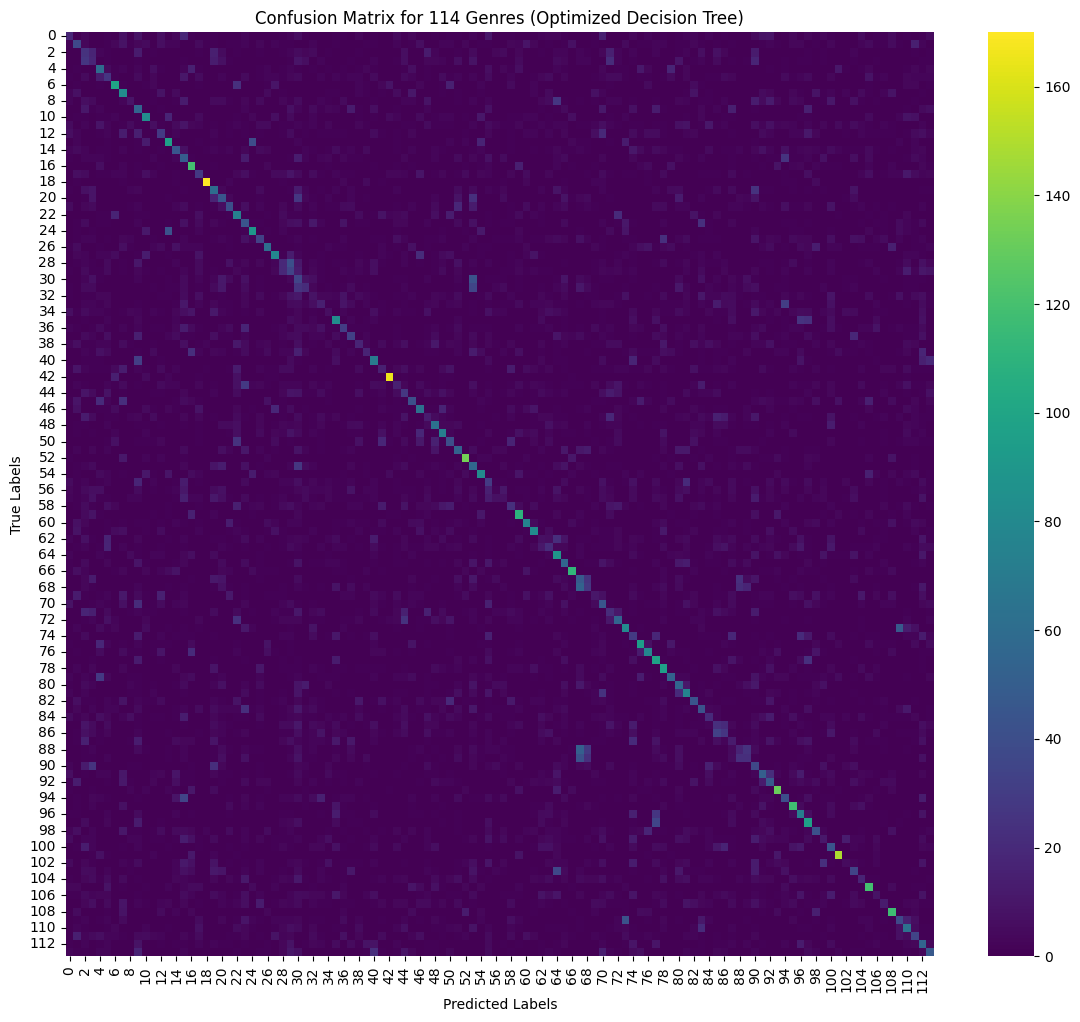

In [ ]:
# Visualize the confusion matrix for the best overall version (typically original features)
plt.figure(figsize=(14, 12))
sns.heatmap(confusion_matrix(y_test, y_pred_orig), annot=False, cmap='viridis')
plt.title("Confusion Matrix for 114 Genres (Optimized Decision Tree)")
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.show()

# 2. KNN (Arya)

# 3. Naive Bayes (Pranav)

In [ ]:
#Import Required Libraries
from sklearn.naive_bayes import GaussianNB, BernoulliNB, MultinomialNB
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import cross_val_score
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
#Prepare Feature Sets for Different Naïve Bayes Variants

# BernoulliNB requires binary features
X_train_binary = (X_train > 0).astype(int)
X_test_binary = (X_test > 0).astype(int)

X_train_pca_binary = (X_train_pca > 0).astype(int)
X_test_pca_binary = (X_test_pca > 0).astype(int)

# MultinomialNB requires non-negative features
scaler_nb = MinMaxScaler()
X_train_nonneg = scaler_nb.fit_transform(X_train)
X_test_nonneg = scaler_nb.transform(X_test)

scaler_nb_pca = MinMaxScaler()
X_train_pca_nonneg = scaler_nb_pca.fit_transform(X_train_pca)
X_test_pca_nonneg = scaler_nb_pca.transform(X_test_pca)

In [ ]:
#Define Naïve Bayes Models
nb_models = {
    "Gaussian NB (Original Features)": (GaussianNB(), X_train, X_test),
    "Gaussian NB (PCA Features)": (GaussianNB(), X_train_pca, X_test_pca),

    "Bernoulli NB (Original Features)": (BernoulliNB(), X_train_binary, X_test_binary),
    "Bernoulli NB (PCA Features)": (BernoulliNB(), X_train_pca_binary, X_test_pca_binary),

    "Multinomial NB (Original Features)": (MultinomialNB(), X_train_nonneg, X_test_nonneg),
    "Multinomial NB (PCA Features)": (MultinomialNB(), X_train_pca_nonneg, X_test_pca_nonneg),
}

In [ ]:
#Train and Evaluate All Naïve Bayes Variants
nb_results = []

for name, (model, Xtr, Xte) in nb_models.items():
    # 5-fold cross-validation on training set
    cv_scores = cross_val_score(model, Xtr, y_train, cv=5, scoring='f1_macro')

    # Train model
    model.fit(Xtr, y_train)

    # Predict on test set
    y_pred = model.predict(Xte)

    # Compute evaluation metrics
    acc = accuracy_score(y_test, y_pred)
    macro_f1 = f1_score(y_test, y_pred, average='macro')

    # Store results
    nb_results.append({
        "Model": name,
        "CV Macro F1 (mean)": round(cv_scores.mean(), 4),
        "CV Macro F1 (std)": round(cv_scores.std(), 4),
        "Test Accuracy": round(acc, 4),
        "Test Macro F1": round(macro_f1, 4)
    })

    # Print detailed results
    print("=" * 70)
    print(name)
    print(f"5-Fold CV Macro F1: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")
    print(f"Test Accuracy: {acc:.4f}")
    print(f"Test Macro F1: {macro_f1:.4f}")
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))

Gaussian NB (Original Features)
5-Fold CV Macro F1: 0.0502 ± 0.0023
Test Accuracy: 0.0861
Test Macro F1: 0.0511

Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00       200
           1       0.00      0.00      0.00       200
           2       0.00      0.00      0.00       200
           3       0.00      0.00      0.00       200
           4       1.00      0.01      0.01       200
           5       0.00      0.00      0.00       200
           6       0.43      0.10      0.16       200
           7       0.62      0.05      0.09       200
           8       0.02      0.03      0.03       200
           9       0.33      0.01      0.02       200
          10       0.12      0.01      0.01       200
          11       0.00      0.00      0.00       200
          12       0.06      0.40      0.10       200
          13       0.08      0.88      0.14       200
          14       0.11      0.17      0.13       200

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Gaussian NB (PCA Features)
5-Fold CV Macro F1: 0.1411 ± 0.0015
Test Accuracy: 0.1779
Test Macro F1: 0.1422

Classification Report:
              precision    recall  f1-score   support

           0       0.08      0.15      0.11       200
           1       0.25      0.13      0.17       200
           2       0.00      0.00      0.00       200
           3       0.03      0.01      0.01       200
           4       0.21      0.33      0.26       200
           5       0.03      0.01      0.01       200
           6       0.35      0.34      0.35       200
           7       0.23      0.04      0.06       200
           8       0.00      0.00      0.00       200
           9       0.08      0.03      0.04       200
          10       0.09      0.04      0.06       200
          11       0.10      0.01      0.03       200
          12       0.12      0.18      0.15       200
          13       0.26      0.19      0.22       200
          14       0.34      0.28      0.30       200
    

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Bernoulli NB (Original Features)
5-Fold CV Macro F1: 0.1152 ± 0.0009
Test Accuracy: 0.1486
Test Macro F1: 0.1163

Classification Report:
              precision    recall  f1-score   support

           0       0.03      0.01      0.01       200
           1       0.18      0.06      0.09       200
           2       0.00      0.00      0.00       200
           3       0.09      0.01      0.01       200
           4       0.16      0.52      0.25       200
           5       0.03      0.01      0.01       200
           6       0.19      0.27      0.22       200
           7       0.21      0.14      0.17       200
           8       0.00      0.00      0.00       200
           9       0.08      0.01      0.02       200
          10       0.13      0.15      0.14       200
          11       0.09      0.01      0.01       200
          12       0.09      0.12      0.10       200
          13       0.18      0.30      0.22       200
          14       0.13      0.25      0.17       20

...

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Multinomial NB (Original Features)
5-Fold CV Macro F1: 0.0767 ± 0.0011
Test Accuracy: 0.0911
Test Macro F1: 0.0749

Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00       200
           1       0.19      0.04      0.07       200
           2       0.01      0.01      0.01       200
           3       0.00      0.00      0.00       200
           4       0.14      0.14      0.14       200
           5       0.00      0.00      0.00       200
           6       0.22      0.15      0.18       200
           7       0.05      0.14      0.07       200
           8       0.00      0.00      0.00       200
           9       0.00      0.00      0.00       200
          10       0.06      0.05      0.05       200
          11       0.00      0.00      0.00       200
          12       0.07      0.07      0.07       200
          13       0.09      0.21      0.13       200
          14       0.06      0.12      0.08       

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Multinomial NB (PCA Features)
5-Fold CV Macro F1: 0.0625 ± 0.0016
Test Accuracy: 0.0863
Test Macro F1: 0.0612

Classification Report:
              precision    recall  f1-score   support

           0       0.05      0.05      0.05       200
           1       0.11      0.07      0.09       200
           2       0.00      0.00      0.00       200
           3       0.00      0.00      0.00       200
           4       0.20      0.10      0.14       200
           5       0.15      0.01      0.02       200
           6       0.21      0.07      0.10       200
           7       0.14      0.14      0.14       200
           8       0.00      0.00      0.00       200
           9       0.00      0.00      0.00       200
          10       0.08      0.04      0.05       200
          11       0.08      0.01      0.01       200
          12       0.08      0.06      0.07       200
          13       0.33      0.01      0.03       200
          14       0.06      0.26      0.10       200
 

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
#Display Summary Table

nb_results_df = pd.DataFrame(nb_results).sort_values(by="Test Macro F1", ascending=False)
print("Naïve Bayes Summary Results:")
display(nb_results_df)

Naïve Bayes Summary Results:


,Model,CV Macro F1 (mean),CV Macro F1 (std),Test Accuracy,Test Macro F1
1,Gaussian NB (PCA Features),0.1411,0.0015,0.1779,0.1422
2,Bernoulli NB (Original Features),0.1152,0.0009,0.1486,0.1163
3,Bernoulli NB (PCA Features),0.0927,0.0024,0.1301,0.0928
4,Multinomial NB (Original Features),0.0767,0.0011,0.0911,0.0749
5,Multinomial NB (PCA Features),0.0625,0.0016,0.0863,0.0612
0,Gaussian NB (Original Features),0.0502,0.0023,0.0861,0.0511


In [ ]:
#Select the Best Naïve Bayes Model

best_nb_name = nb_results_df.iloc[0]["Model"]
print("Best Naïve Bayes Model:", best_nb_name)

best_nb_model, best_Xtr, best_Xte = nb_models[best_nb_name]
best_nb_model.fit(best_Xtr, y_train)
best_nb_pred = best_nb_model.predict(best_Xte)

Best Naïve Bayes Model: Gaussian NB (PCA Features)


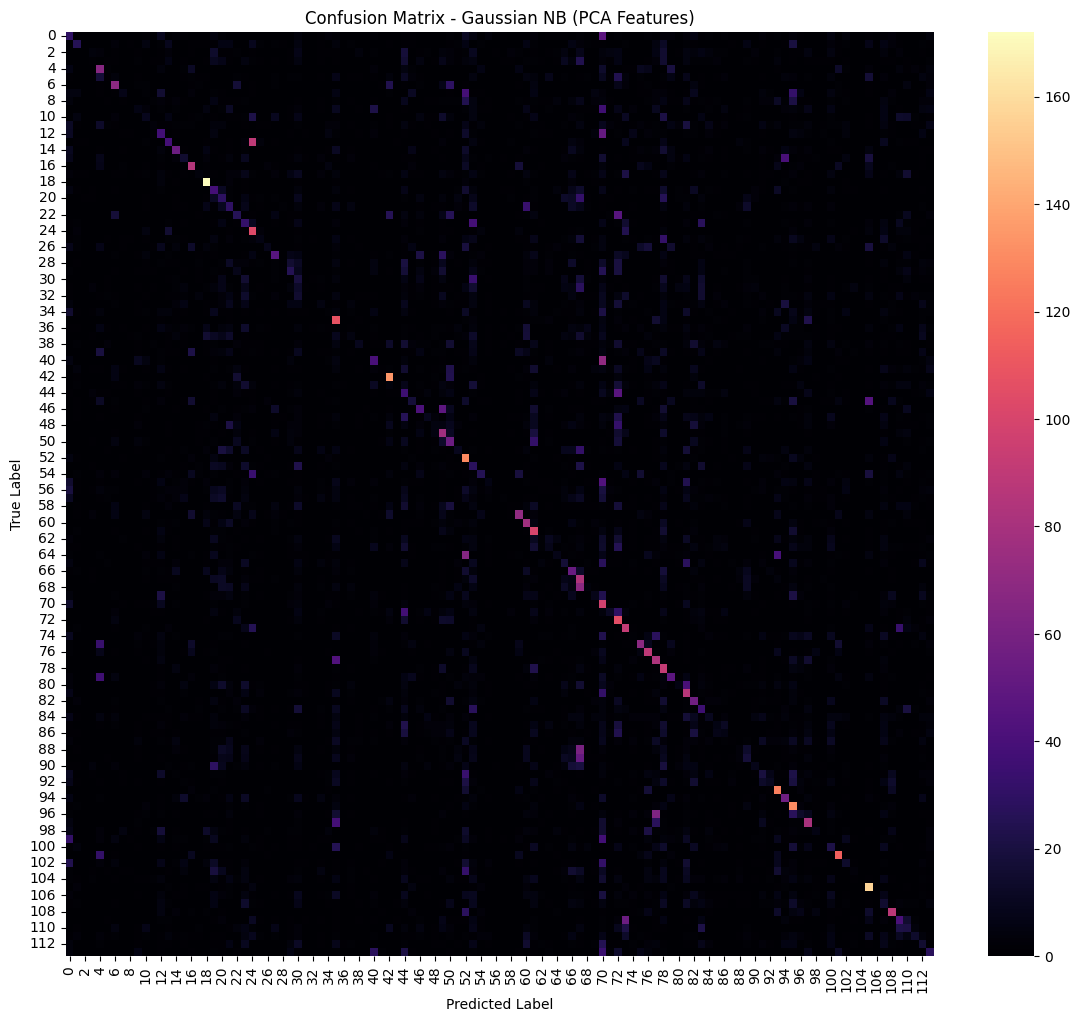

In [ ]:
#Confusion Matrix for the Best Naïve Bayes Model

plt.figure(figsize=(14, 12))
sns.heatmap(confusion_matrix(y_test, best_nb_pred), annot=False, cmap='magma')
plt.title(f"Confusion Matrix - {best_nb_name}")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

In [ ]:
#Final Performance of Best Naïve Bayes Model
best_nb_accuracy = accuracy_score(y_test, best_nb_pred)
best_nb_macro_f1 = f1_score(y_test, best_nb_pred, average='macro')

print("Final Best Naïve Bayes Performance")
print(f"Accuracy: {best_nb_accuracy:.4f}")
print(f"Macro F1-score: {best_nb_macro_f1:.4f}")

Final Best Naïve Bayes Performance
Accuracy: 0.1779
Macro F1-score: 0.1422
